# Chapter 7. n-step 부트스트래핑, 적격흔적, 그리고 계획 — 실습: Dyna-Q

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml2/chapter07_3_dyna_q.ipynb)

책 본문: [Section 7.3 계획과 학습: Dyna-Q](https://smhanlab.com/book-ml/kor/ml2/chapter07/3.html)

이 노트북은 책 7.3절의 **Dyna-Q**를 그대로 구현하고, "계획(planning)이
학습을 얼마나 빠르게 하는가"를 작은 5×5 격자 환경에서 에피소드 수로
재봅니다. 매 실제 스텝마다 학습된 모델을 이용해 `planning_steps`번
가상 TD(0) 갱신을 끼워 넣는 것이 Dyna-Q의 전부인데, `planning_steps=0`이면
순수 Q-learning으로 돌아가기 때문에 A/B 비교가 그대로 됩니다.

## 1. 5×5 격자 환경 만들기

출발점 (4,0)(아래 왼쪽), 목표 (0,4)(위 오른쪽), 4방향 이동, 벽에 부딪히면
같은 자리에 남는다. 이동마다 보상 -1, 목표에 도착하면 보상 0으로 에피소드 종료.

\(\gamma=1\)(유한하고 반드시 끝나는 과업이라 할인이 불필요),
\(\alpha=0.1\), \(\varepsilon=0.1\).

In [1]:
import random

import matplotlib
import matplotlib.pyplot as plt

ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right (row, col)
START, GOAL = (4, 0), (0, 4)

def step(s, a):
    r, c = s
    nr = min(max(r + ACTIONS[a][0], 0), 4)
    nc = min(max(c + ACTIONS[a][1], 0), 4)
    ns = (nr, nc)
    if ns == GOAL:
        return ns, 0.0, True
    return ns, -1.0, False

# 간단한 sanity check: 벽 반사, 목표 보상
print(step(START, 0))   # up    -> (3, 0), -1, False
print(step(START, 3))   # right -> (4, 1), -1, False
print(step(GOAL, 0))    # goal self-loop: (0,4), 0, True

((3, 0), -1.0, False)
((4, 1), -1.0, False)
((0, 4), 0.0, True)


## 2. 참값(정답) 먼저 구하기 — 벨만방정식의 고정점

학습 결과가 "잘" 나온다는 것을 판단하려면 정답이 필요한다. 이 환경은
전이확률/보상이 전부 알려졌으므로 **가치반복(value iteration)**으로
정확한 \(Q^{*}\)를 구할 수 있다(Chapter 4.1의 방법). 손으로 대조할 수 있는
숫자: 출발점에서 목표까지 맨해튼 거리 8 → 최적 리턴은 **정확히 -7**이고,
출발점에서 "위"/"오른쪽"이 모두 최단 경로의 첫 스텝이므로
\(Q^{*}(\text{출발}, \text{위}) = Q^{*}(\text{출발}, \text{오른쪽}) = -7\),
"아래"/"왼쪽"은 -8이다.

In [2]:
states = [(r, c) for r in range(5) for c in range(5)]
Q_star = {(s, a): 0.0 for s in states for a in range(4)}
for _ in range(300):
    delta = 0.0
    for s in states:
        for a in range(4):
            ns, r, done = step(s, a)
            target = r + (0.0 if done else max(Q_star[(ns, x)] for x in range(4)))
            delta = max(delta, abs(target - Q_star[(s, a)]))
            Q_star[(s, a)] = target
    if delta < 1e-12:
        break

print("converged at iteration", _ + 1)
names = ["up", "down", "left", "right"]
print("Q*(start,·) =", {names[a]: Q_star[(START, a)] for a in range(4)})
print("V*(start)   =", max(Q_star[(START, a)] for a in range(4)))

assert abs(Q_star[(START, 0)] - (-7.0)) < 1e-6  # up
assert abs(Q_star[(START, 3)] - (-7.0)) < 1e-6  # right
assert abs(Q_star[(START, 1)] - (-8.0)) < 1e-6  # down
assert abs(Q_star[(START, 2)] - (-8.0)) < 1e-6  # left
print("모두 일치! 가치반복 결과가 손으로 계산한 참값(위/오른쪽 -7, 아래/왼쪽 -8)과 정확히 같습니다.")

converged at iteration 9
Q*(start,·) = {'up': -7.0, 'down': -8.0, 'left': -8.0, 'right': -7.0}
V*(start)   = -7.0
모두 일치! 가치반복 결과가 손으로 계산한 참값(위/오른쪽 -7, 아래/왼쪽 -8)과 정확히 같습니다.


## 3. Dyna-Q 구현 (책 7.3절 코드)

매 스텝마다 (1) 실제 경험으로 TD(0) 갱신, (2) `model[(s,a)] = (r, s')`로
모델 저장(마지막 경험 하나만 저장 — 결정론적 환경 가정), (3) 모델에서
무작위 (s,a)를 `planning_steps`번 뽑아 모델 예측으로 같은 TD(0) 갱신
(= 계획). 실제 갱신과 계획 갱신이 **같은 Q 테이블**을 공유하는 것이 핵심.

`planning_steps=0`이면 3번 단계가 사라져 순수 Q-learning이 된다.

In [3]:
def dyna_q_grid(n_episodes, planning_steps, alpha=0.1, gamma=1.0, epsilon=0.1, seed=0):
    rng = random.Random(seed)
    Q, model = {}, {}
    returns, q_start = [], []
    for _ in range(n_episodes):
        s, ret = START, 0.0
        for _ in range(100):  # 에피소드 최대 길이(안전장치 — 실제로는 8스텝 내 종료)
            a = rng.randrange(4) if rng.random() < epsilon \
                else max(range(4), key=lambda x: Q.get((s, x), 0.0))
            ns, r, done = step(s, a)
            # 1) 실제 경험으로 TD(0) 갱신
            Q[(s, a)] = Q.get((s, a), 0.0) + alpha * (
                r + gamma * max(Q.get((ns, x), 0.0) for x in range(4)) - Q.get((s, a), 0.0))
            # 2) 모델 갱신 (결정론적 환경 가정: 마지막 경험만 저장)
            model[(s, a)] = (r, ns)
            # 3) 계획: 모델에서 무작위 (s,a)를 뽑아 가상 TD(0) 갱신
            for _ in range(planning_steps):
                (ps, pa), (pr, pns) = rng.choice(list(model.items()))
                Q[(ps, pa)] = Q.get((ps, pa), 0.0) + alpha * (
                    pr + gamma * max(Q.get((pns, x), 0.0) for x in range(4)) - Q.get((ps, pa), 0.0))
            s, ret = ns, ret + r
            if done:
                break
        returns.append(ret)
        q_start.append(max(Q.get((START, x), 0.0) for x in range(4)))
    return Q, returns, q_start, model

## 4. 실험: `planning_steps`를 0 / 5 / 10 / 30으로 비교

각 설정을 400 에피소드 학습시킨다. 수렴 지표는 **"25에피소드 평균 리턴이
최적치(-7)에서 1.0 이내(> -8)로 처음 들어가는 에피소드 수"** — 1개 에피소드의
행운/불운을 25에피소드 평균으로 걸러서 "이제 거의 최적이다"를 판정하는 것.

In [4]:
N_EP = 400
PS_LIST = [0, 5, 10, 30]

def first_episode_where(returns, thr=-8.0, window=25):
    for i, r in enumerate(returns):
        if i + 1 >= window and sum(returns[i - window + 1:i + 1]) / window > thr:
            return i + 1
    return None

results = {}
for ps in PS_LIST:
    Q, returns, q_start, model = dyna_q_grid(N_EP, ps, seed=0)
    first = first_episode_where(returns)
    results[ps] = (Q, returns, q_start, model, first)
    print(f"planning_steps={ps:2d}: 수렴 에피소드 = {first}, "
          f"마지막 25에피소드 평균 리턴 = {sum(returns[-25:]) / 25:.2f}, "
          f"모델 크기 = {len(model)}/100")

planning_steps= 0: 수렴 에피소드 = 334, 마지막 25에피소드 평균 리턴 = -7.52, 모델 크기 = 96/100
planning_steps= 5: 수렴 에피소드 = 75, 마지막 25에피소드 평균 리턴 = -7.72, 모델 크기 = 96/100
planning_steps=10: 수렴 에피소드 = 52, 마지막 25에피소드 평균 리턴 = -7.64, 모델 크기 = 96/100


planning_steps=30: 수렴 에피소드 = 35, 마지막 25에피소드 평균 리턴 = -7.60, 모델 크기 = 95/100


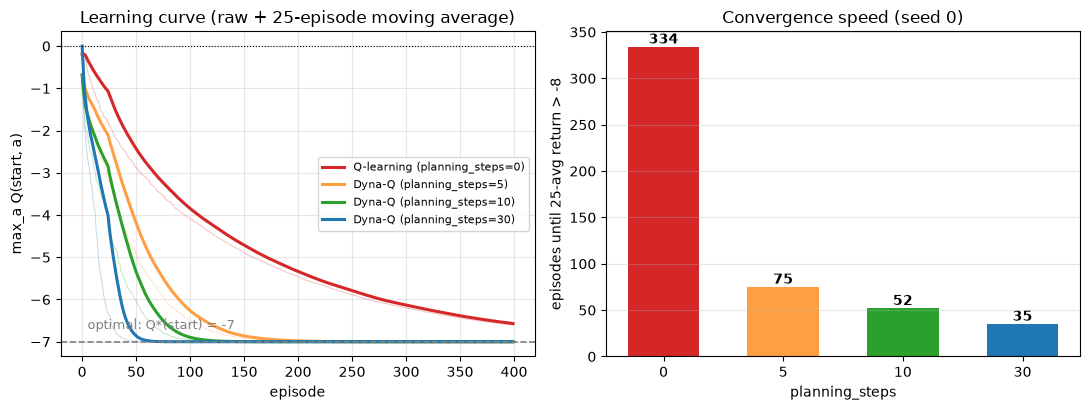

In [5]:
def moving_avg(x, w=25):
    return [sum(x[max(0, i - w + 1):i + 1]) / min(i + 1, w) for i in range(len(x))]

COLORS = {0: "#d62728", 5: "#ff9f43", 10: "#2ca02c", 30: "#1f77b4"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for ps in PS_LIST:
    _, returns, q_start, _, _ = results[ps]
    label = "Q-learning (planning_steps=0)" if ps == 0 else f"Dyna-Q (planning_steps={ps})"
    ax1.plot(moving_avg(q_start), color=COLORS[ps], lw=2.2, label=label)
    ax1.plot(q_start, color=COLORS[ps], alpha=0.25, lw=0.8)
ax1.axhline(0.0, color="k", lw=0.8, ls=":")
ax1.axhline(-7.0, color="gray", lw=1.2, ls="--")
ax1.annotate("optimal: Q*(start) = -7", xy=(5, -6.7), color="gray", fontsize=9)
ax1.set_xlabel("episode")
ax1.set_ylabel("max_a Q(start, a)")
ax1.set_title("Learning curve (raw + 25-episode moving average)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

bar_vals = []
for ps in PS_LIST:
    first = results[ps][4]
    bar_vals.append(first if first is not None else N_EP)
bars = ax2.bar([str(p) for p in PS_LIST], bar_vals, color=[COLORS[p] for p in PS_LIST], width=0.6)
for b, v, ps in zip(bars, bar_vals, PS_LIST):
    ax2.annotate(">400" if v >= N_EP else str(v),
                 xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_xlabel("planning_steps")
ax2.set_ylabel("episodes until 25-avg return > -8")
ax2.set_title("Convergence speed (seed 0)")
ax2.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## 5. 결과 해석

세 가지가 보인다:

1. **가속은 극적** — `planning_steps=30`이 순수 Q-learning 대비 약 9~10배
   빨리 수렴한다. 실제 상호작용 35회로 계획 없이는 300회 넘게 걸렸던
   학습이 끝난다.
2. **한계 효과 감소** — 0→10으로 늘리면 크게(약 6배) 빨라지지만,
   10→30으로 더 늘려도 소폭(약 1.5배)만 줄어든다. `planning_steps`는
   `alpha`, `epsilon`과 같은 하이퍼파라미터로 검증 성능으로 튜닝할 것.
3. **모델 커버리지** — 400 에피소드 후 100개 (s,a) 중 약 95~96개만 모델에
   들어간다. 계획은 모델에 *있는* (s,a)만을 재사용할 수 있으므로,
   이 커버리지가 계획의 품질 상한선을 정한다.

In [6]:
def greedy_path(Q, max_steps=50):
    s, path, ret = START, [START], 0.0
    for _ in range(max_steps):
        a = max(range(4), key=lambda x: Q.get((s, x), 0.0))
        ns, r, done = step(s, a)
        path.append(ns)
        ret += r
        s = ns
        if done:
            break
    return path, ret

print("greedy policy (argmax Q) and accuracy vs Q*:")
for ps in PS_LIST:
    Q, _, _, model, first = results[ps]
    path, ret = greedy_path(Q)
    q_best = max(Q.get((START, x), 0.0) for x in range(4))
    # accuracy: mean |Q - Q*| over the (s,a) pairs the agent actually visited
    visited = [p for p in Q_star if p in Q]
    mae = sum(abs(Q[p] - Q_star[p]) for p in visited) / len(visited)
    print(f"ps={ps:2d}: greedy {len(path)-1}스텝 리턴 {ret:5.1f} (최적 -7)  "
          f"max Q(start)={q_best:5.2f}  방문 (s,a)={len(visited)}/100  "
          f"mean|Q-Q*|={mae:.3f}")

greedy policy (argmax Q) and accuracy vs Q*:
ps= 0: greedy 8스텝 리턴  -7.0 (최적 -7)  max Q(start)=-6.61  방문 (s,a)=96/100  mean|Q-Q*|=0.939
ps= 5: greedy 8스텝 리턴  -7.0 (최적 -7)  max Q(start)=-7.00  방문 (s,a)=96/100  mean|Q-Q*|=0.000
ps=10: greedy 8스텝 리턴  -7.0 (최적 -7)  max Q(start)=-7.00  방문 (s,a)=96/100  mean|Q-Q*|=0.000
ps=30: greedy 8스텝 리턴  -7.0 (최적 -7)  max Q(start)=-7.00  방문 (s,a)=95/100  mean|Q-Q*|=0.000


## 정리

Dyna-Q = **Q-learning + "본 (s,a)의 마지막 (r,s')를 기억하는 표"**.
실제 경험 1회당 계획 `planning_steps`번을 끼워 넣으면, 같은 실제
경험으로 Q를 갱신하는 횟수를 `1 + planning_steps`배 늘려
**실세계 학습 시간을 크게 줄인다**.

주의할 점(책 7.3절 "자주 하는 실수"와 대응):

- `model`은 희소 딕셔너리 — 아직 경험하지 않은 (s,a)는 *없으므로*
  `model.items()`에서 뽑아야 하고 `model[(s,a)]`로 직접 조회하면
  `KeyError`.
- 실제 갱신과 계획 갱신은 **같은 Q 테이블**을 써야 한다. 별도 테이블로
  나누면 계획의 결과가 실제 행동에 반영되지 않아 가속 효과가 0이 된다.
- `planning_steps`를 과도하게 늘리면 모델 오차가 "복리"로 증식할 수 있다.

이 "학습이 만든 모델로 계획하고, 계획이 학습을 가속한다"는 루프가
Chapter 15의 MCTS/AlphaZero로 이어진다(신경망이 모델의 역할을, MCTS가
계획의 역할을 맡은 같은 구조).